In [122]:
import numpy as np
import pandas as pd

In [123]:
x_train = np.load('/home/matrioszka/ptb-xl/X_train.npy')
y_train = np.load('/home/matrioszka/ptb-xl/y_train.npy', allow_pickle=True)
x_test = np.load('/home/matrioszka/ptb-xl/X_test.npy')
y_test = np.load('/home/matrioszka/ptb-xl/y_test.npy', allow_pickle=True)

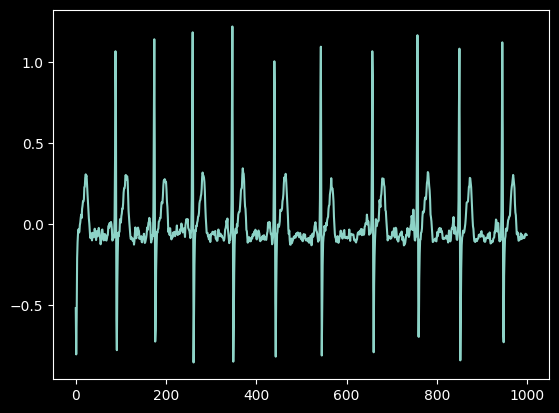

In [124]:
import matplotlib.pyplot as plt
plt.plot(x_train[10000, :, 0])

In [121]:
from scipy.signal import butter, filtfilt, find_peaks

def preprocess_ecg_dataset(x, y, fs, fixed_length=300,
                           lowcut=0.5, highcut=40,
                           threshold=0.9):
    """
    x_train shape: (n_recordings, n_samples, 12)
    fs: sampling frequency (Hz)
    fixed_length: final padded beat length
    """

    def bandpass_filter(signal):
        nyq = 0.5 * fs
        b, a = butter(3, [lowcut/nyq, highcut/nyq], btype='band')
        return filtfilt(b, a, signal)

    def normalize_01(signal):
        return (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    all_beats = []
    beat_labels = []

    for i in range(x.shape[0]):

        # Use Lead II for R-peak detection (index 1)
        signal = x[i, :, 1]

        # 1) Bandpass filter
        signal_filt = bandpass_filter(signal)

        # 2) Normalize to [0,1]
        signal_norm = normalize_01(signal_filt)
        mean = np.mean(signal_norm)
        std = np.std(signal_norm)

        # 3) Detect R-peaks (local maxima + threshold)
        min_distance = int(0.1 * fs)  # 100 ms refractory period

        r_peaks, properties = find_peaks(
            signal_norm,
            height=threshold,
            distance=min_distance
        )

        # Need at least 2 peaks to compute RR
        if len(r_peaks) < 2:
            continue

        # 4) Median RR interval (nominal period T)
        rr_intervals = np.diff(r_peaks)
        T = int(np.median(rr_intervals))

        beat_length = int(1.2 * T)
        #half_len = beat_length // 2

        # 5) Extract beats
        beats = []

        for peak in r_peaks:
            end = peak + beat_length

            if end > len(signal_norm):
                continue

            beat = signal_norm[peak:end]
            beat_zero_mean = (beat - mean) / (std + 1e-8)
            beats.append(beat_zero_mean)

        if len(beats) == 0:
            continue

        # 6) Zero-pad to fixed length
        padded = np.zeros((len(beats), fixed_length))

        for j, beat in enumerate(beats):
            length = min(len(beat), fixed_length)
            padded[j, :length] = beat[:length]

        all_beats.append(padded)
        beat_labels.extend([y[i]] * len(beats))

    if len(all_beats) == 0:
        return None

    return np.vstack(all_beats), np.array(beat_labels)

In [134]:
beats_train, labels_train = preprocess_ecg_dataset(x_train, y_train, 100, fixed_length=150, threshold=0.8)
beats_test, labels_test = preprocess_ecg_dataset(x_test, y_test, 100, fixed_length=150, threshold=0.8)

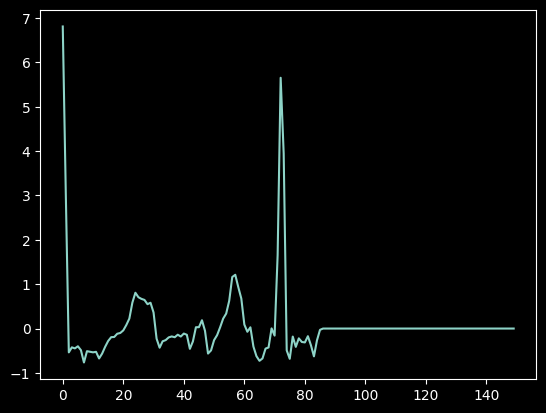

In [183]:
plt.plot(beats_test[1908, :])

In [184]:
print(pd.DataFrame(labels_train).value_counts())

0   
NORM    85976
MI      26637
STTC    23921
CD      23337
HYP      5267
Name: count, dtype: int64


In [185]:
np.save('beats_train_x.npy', beats_train)
np.save('beats_train_y.npy', labels_train)
np.save('beats_test_x.npy', beats_test)
np.save('beats_test_y.npy', labels_test)